# llama3.1:8b — how well does it label DMPs?

The pipeline reads a Data Management Plan and labels every piece of text as one of
five things: a **title**, a **section heading**, a **description**, a **question**, or
an **answer**.

This notebook shows how close it gets to a human annotation of the same 10 documents,
and then looks at three concrete cases where it goes wrong.


In [1]:
import os
from pathlib import Path

if Path.cwd().name == 'notebooks':
    os.chdir(Path.cwd().parent)

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from dmpbridge.core import paths
from dmpbridge.evaluation.evaluate import (
    load_method as load_method_old, extract_gold, _match_structured,
    _confusion_from_match, micro_prf1, compute_f1_rows, resolve_old_gt_path,
)
from dmpbridge.evaluation.annotation_rules import (
    convert_tag_to_final, load_method_new, resolve_new_gt_path, FINAL_DIR,
)

MODEL, TAG = 'llama3.1:8b', 'llama3.1-8b_pdfplumber_whole_doc'
BLUE, GREEN, GREY = '#1d4ed8', '#059669', '#94a3b8'

df_a, conf_a, err_a = load_method_old(TAG, exclude=[])
convert_tag_to_final(TAG)
df_b, conf_b, err_b = load_method_new(TAG, exclude=[])
print(f'{MODEL} — {len(df_a)} documents')


llama3.1:8b — 10 documents


## 1 — The score

Three numbers, all out of 100:

| | |
|---|---|
| **Found** | of everything in the human annotation, how much did it locate? |
| **Correct** | of everything it produced, how much was right? |
| **F1** | the two combined — the single number to judge it on |

A model cannot score well on F1 by playing safe and producing very little, or by
producing everything it can think of. It has to do both well.


  Found      72.7%
  Correct    53.9%
  F1         61.9%


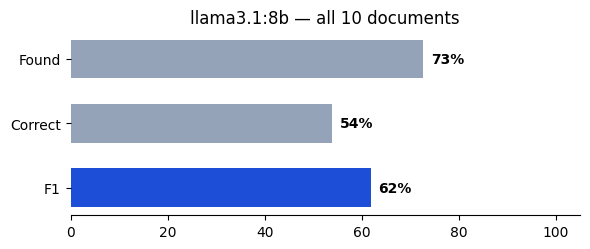

In [2]:
m = micro_prf1(conf_a)
print(f'  Found     {m["recall"] * 100:5.1f}%')
print(f'  Correct   {m["precision"] * 100:5.1f}%')
print(f'  F1        {m["f1"] * 100:5.1f}%')

fig, ax = plt.subplots(figsize=(6, 2.6))
vals = [m['recall'] * 100, m['precision'] * 100, m['f1'] * 100]
bars = ax.barh(['Found', 'Correct', 'F1'], vals,
               color=[GREY, GREY, BLUE], height=0.6)
for b, v in zip(bars, vals):
    ax.text(v + 1.5, b.get_y() + b.get_height() / 2, f'{v:.0f}%',
            va='center', fontweight='bold')
ax.set_xlim(0, 105)
ax.invert_yaxis()
ax.set_title(f'{MODEL} — all 10 documents')
sns.despine(left=True)
plt.tight_layout()
plt.show()


## 2 — Which of the five labels are hard

`in annotation` is how many examples of that label a human marked. Where that number
is small, the score moves a lot on very little evidence.


label                         F1   in annotation
------------------------------------------------
title                      90.0%              10
section.title              68.6%              43
section.description        75.0%               8
question.text               4.2%              16
answer.text                72.6%              55


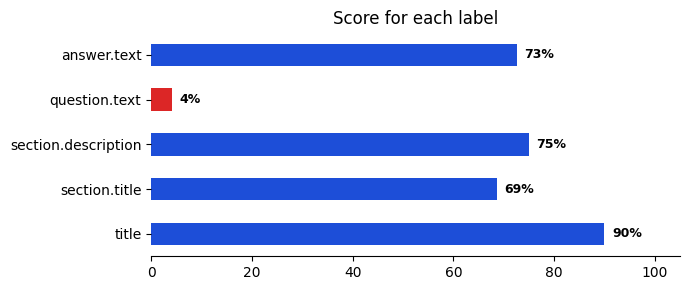

In [3]:
fa = compute_f1_rows(conf_a).set_index('label')

print(f"{'label':<24}{'F1':>8}{'in annotation':>16}")
print('-' * 48)
for lab, r in fa.iterrows():
    print(f"{lab:<24}{r['f1'] * 100:>7.1f}%{int(r['support']):>16}")

ax = (fa['f1'] * 100).plot(kind='barh', figsize=(7, 3),
                           color=[BLUE if v > 0.5 else '#dc2626' for v in fa['f1']])
for i, v in enumerate(fa['f1'] * 100):
    ax.text(v + 1.5, i, f'{v:.0f}%', va='center', fontweight='bold', fontsize=9)
ax.set_xlim(0, 105)
ax.set_ylabel('')
ax.set_title('Score for each label')
sns.despine(left=True)
plt.tight_layout()
plt.show()


---

## 3 — Three things that go wrong

The score says *how much*. These say *what*.


### Example 1 — a question mistaken for a heading

Many DMPs have lettered sub-questions under each section:

> **Element 1: Data Type:**  ← this is the section heading
> **A. Types and amount of scientific data expected…**  ← this is a question
> *This project will analyse deidentified data from…*  ← this is the answer

The model often promotes the lettered question to a heading. When it does, two things
break at once: a real question goes unfound, and a heading appears that shouldn't exist.


In [4]:
as_heading = err_a[(err_a['true'] == 'question.text')
                   & (err_a['pred'] == 'section.title')]

print(f'This happened {len(as_heading)} times. The first few:')
print()
for _, e in as_heading.head(5).iterrows():
    print(f"  {e['text'][:78]}")


This happened 12 times. The first few:

  B. Scientific data that will be preserved and shared, and the rationale for do
  C. Metadata, other relevant data, and associated documentation:
  A. Repository where scientific data and metadata will be archived:
  B. How scientific data will be findable and identifiable:
  C. When and how long the scientific data will be made available:


### Example 2 — an answer chopped into questions

The second mistake is stranger. The model takes fragments from the middle of the
researcher's own writing and labels them as questions — even though they are plainly
not questions, just pieces of sentences.


In [5]:
invented = err_a[(err_a['true'] == 'no_gold_match')
                 & (err_a['pred'] == 'question.text')]

print(f'{len(invented)} pieces of text were called questions but are not in the annotation at all:')
print()
for _, e in invented.head(5).iterrows():
    print(f"  {e['text'][:78]}")


23 pieces of text were called questions but are not in the annotation at all:

  about other studies.
  (i) the SOL-VIDA Study – Data requests may be made by following instructions o
  Roles & Responsibilities. For the proposed research, Director Samuel Stupp wit
  the course of the proposed research and which of these are considered Digital 
  applicable, a description of documentation plans, annotation of relevant softw


### Example 3 — the document it handled worst

Scores vary a lot between documents. Below is the weakest one, with everything the
model got wrong on it laid out.


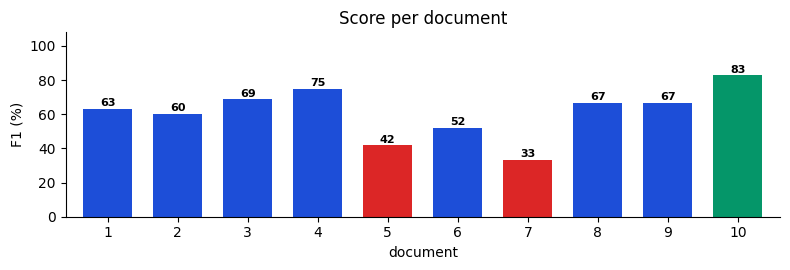

Weakest document: sample7  (33.3%)
  Note: this document is very small — only 3 items — so one
  mistake moves its score a long way. Treat it as illustrative, not typical.

The human annotation has 3 items. The model:
  got right            1
  labelled wrongly     1
  did not find         1
  invented             1

  should be question.text        called not found           
      Resource/Data Sharing Plan
  should be answer.text          called section.title       
      The study investigators are committed to the open and timely dissemina


In [6]:
rows = []
for n in range(1, 11):
    p = FINAL_DIR / TAG / f'sample{n}.json'
    if not p.exists():
        continue
    gold = extract_gold(resolve_new_gt_path(n))
    recs, extras = _match_structured(p, gold)
    m = micro_prf1(_confusion_from_match(recs, extras))
    rows.append({'doc': n, 'f1': m['f1'] * 100})
per_doc = pd.DataFrame(rows).set_index('doc')

ax = per_doc['f1'].plot(kind='bar', figsize=(8, 2.8), width=0.7,
                        color=['#dc2626' if v < 50 else GREEN if v >= 75 else BLUE
                               for v in per_doc['f1']])
for i, v in enumerate(per_doc['f1']):
    ax.text(i, v + 1.5, f'{v:.0f}', ha='center', fontsize=8, fontweight='bold')
ax.set_ylim(0, 108)
ax.set_ylabel('F1 (%)')
ax.set_xlabel('document')
ax.set_xticklabels(per_doc.index, rotation=0)
ax.set_title('Score per document')
sns.despine()
plt.tight_layout()
plt.show()

# Rank and inspect using the same annotation, or the numbers will not line up.
worst = int(per_doc['f1'].idxmin())
gold = extract_gold(resolve_new_gt_path(worst))
recs, extras = _match_structured(FINAL_DIR / TAG / f'sample{worst}.json', gold)

print(f'Weakest document: sample{worst}  ({per_doc.loc[worst, "f1"]:.1f}%)')
if len(gold) < 6:
    print(f'  Note: this document is very small — only {len(gold)} items — so one')
    print('  mistake moves its score a long way. Treat it as illustrative, not typical.')
print()
print(f'The human annotation has {len(gold)} items. The model:')
print(f"  got right          {sum(1 for r in recs if r['pred_label'] == r['gold_label']):>3}")
print(f"  labelled wrongly   {sum(1 for r in recs if r['pred_label'] and r['pred_label'] != r['gold_label']):>3}")
print(f"  did not find       {sum(1 for r in recs if r['pred_label'] is None):>3}")
print(f'  invented           {len(extras):>3}')
print()
for r in recs:
    if r['pred_label'] != r['gold_label']:
        called = r['pred_label'] or 'not found'
        print(f"  should be {r['gold_label']:<20} called {called:<20}")
        print(f"      {r['gold_text'][:70]}")


---

## What this means

**The hard part is telling headings, questions and answers apart** — not reading the
PDF. Titles are almost always right; the confusion is between the three kinds of body
text, which look similar and differ mainly by their role in the document.

**Both kinds of mistake cost the same.** Missing something real and inventing something
that isn't there are penalised equally, which is why a model that over-produces scores
no better than one that under-produces.

**The evidence is thin in places.** Some labels have only a handful of examples across
all 10 documents, so their scores should be read as a rough indication rather than a
measurement. Running the same thing twice already moves the overall score by about
3 points.

For the mechanics of how the score is calculated, and for the annotation rules, see
`annotation_conversion_test.ipynb`.
